<a href="https://colab.research.google.com/github/MBR4V0/Python/blob/main/Rascunho_Base_Inicia%C3%A7%C3%A3o_Cientifica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 61.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import time
import timeit

def jeito_devagar_para_calcular_moda(lista_de_numeros):
  result_dict = {} # cria um dicionario
  for i in lista_de_numeros: #percorre a lista e conta quantas vezes o numero aparece
    if i not in result_dict:
      result_dict[i] = 1
    else:
      result_dict[i] += 1
  val_moda = [] #cria uma lista pois o conjunto pode ter mais de uma moda
  maior_ocorrencia = max(result_dict.values()) #qual a maior ocorrencia?
  for key, value in result_dict.items():
    if value == maior_ocorrencia:
      val_moda.append(key)
  return val_moda
inteiro_aleatorios = np.random.randint(1,1_00_000,1_000_000) #mil valores
inicio = time.time()
jeito_devagar_para_calcular_moda(inteiro_aleatorios)
fim = time.time()
print ( fim - inicio )
temp_moda = timeit.Timer(stmt="jeito_devagar_para_calcular_moda(inteiro_aleatorios)", setup="from __main__ import jeito_devagar_para_calcular_moda, inteiro_aleatorios")
tempo_gasto = temp_moda.timeit(number=1) #rode apenas 1 vez
print(f"Tempo de execução:{tempo_gasto} segundos")

0.8527359962463379
Tempo de execução:0.8468901100000039 segundos


Busca classica em Grafos


In [ ]:
import time
from collections import deque

# grafo simples (não ponderado)
graph = {
    0: [1, 2],
    1: [3, 4],
    2: [5],
    3: [],
    4: [6],
    5: [7],
    6: [],
    7: []
}

def bfs(graph, start, target):
    queue = deque([start])
    visited = set()

    while queue:
        node = queue.popleft()

        if node == target:
            return node

        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])

    return None


# medir tempo
inicio = time.time()
for _ in range(10000):
    bfs(graph, 0, 7)
fim = time.time()

print("Tempo BFS:", fim - inicio)

Tempo BFS: 0.021116018295288086


BUSCA QUÂNTICA” COM CIRQ (GROVER SIMPLIFICADO)


In [ ]:
!pip install cirq --quiet

In [ ]:
import cirq
import numpy as np
import time

In [ ]:
n_qubits = 3
qubits = cirq.LineQubit.range(n_qubits)

N = 2 ** n_qubits
target = 5  # elemento que queremos encontrar

In [ ]:
def grover_oracle(target, qubits):
    circuit = cirq.Circuit()

    # transforma target em binário
    bits = format(target, f"0{len(qubits)}b")

    # aplica X nos bits que são 0 (para transformar |target> em |111>)
    for i, bit in enumerate(bits):
        if bit == '0':
            circuit.append(cirq.X(qubits[i]))

    # multi-controlled Z (marca o estado |111>)
    # The Z gate acts on the last qubit, controlled by all others.
    # Corrected line:
    circuit.append(cirq.Z(qubits[-1]).controlled_by(*qubits[:-1]))

    # desfaz X
    for i, bit in enumerate(bits):
        if bit == '0':
            circuit.append(cirq.X(qubits[i]))

    return circuit

In [ ]:
def diffusion(qubits):
    circuit = cirq.Circuit()

    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.X.on_each(*qubits))

    # The Z gate acts on the last qubit, controlled by all others.
    # Corrected line:
    circuit.append(cirq.Z(qubits[-1]).controlled_by(*qubits[:-1]))

    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.H.on_each(*qubits))

    return circuit

In [ ]:
iterations = int(np.pi / 4 * np.sqrt(N))
print("Iterações ótimas:", iterations)

Iterações ótimas: 2


In [ ]:
import cirq
import numpy as np

def grover_oracle(target, qubits):
    ops = []

    bits = format(target, f"0{len(qubits)}b")

    # X nos bits 0
    for i, bit in enumerate(bits):
        if bit == '0':
            ops.append(cirq.X(qubits[i]))

    # multi-controlled Z (via H + MCX + H)
    ops.append(cirq.H(qubits[-1]))
    ops.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))  # para 3 qubits
    ops.append(cirq.H(qubits[-1]))

    # desfaz X
    for i, bit in enumerate(bits):
        if bit == '0':
            ops.append(cirq.X(qubits[i]))

    return ops

In [ ]:
import cirq
import numpy as np
import time

# -----------------------
# CONFIGURAÇÃO
# -----------------------
n_qubits = 3
qubits = cirq.LineQubit.range(n_qubits)

target = 5
N = 2 ** n_qubits
iterations = int(np.pi / 4 * np.sqrt(N))

# -----------------------
# ORACLE
# -----------------------
def grover_oracle(target, qubits):
    ops = []

    bits = format(target, f"0{len(qubits)}b")

    for i, bit in enumerate(bits):
        if bit == '0':
            ops.append(cirq.X(qubits[i]))

    ops.append(cirq.H(qubits[-1]))
    ops.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    ops.append(cirq.H(qubits[-1]))

    for i, bit in enumerate(bits):
        if bit == '0':
            ops.append(cirq.X(qubits[i]))

    return ops

# -----------------------
# DIFFUSION
# -----------------------
def diffusion(qubits):
    ops = []

    ops.append(cirq.H.on_each(*qubits))
    ops.append(cirq.X.on_each(*qubits))

    ops.append(cirq.H(qubits[-1]))
    ops.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    ops.append(cirq.H(qubits[-1]))

    ops.append(cirq.X.on_each(*qubits))
    ops.append(cirq.H.on_each(*qubits))

    return ops

# -----------------------
# CIRCUITO
# -----------------------
circuit = cirq.Circuit()

circuit.append(cirq.H.on_each(*qubits))

for _ in range(iterations):
    circuit.append(grover_oracle(target, qubits))
    circuit.append(diffusion(qubits))

circuit.append(cirq.measure(*qubits, key="result"))

# -----------------------
# SIMULAÇÃO + TEMPO
# -----------------------
simulator = cirq.Simulator()

# tempo total de construção (opcional)
start_build = time.time()

# já construído acima
end_build = time.time()

# tempo de execução (simulação)
start_run = time.time()
result = simulator.run(circuit, repetitions=2000)
end_run = time.time()

# -----------------------
# RESULTADOS
# -----------------------
print("Iterações Grover:", iterations)
print("Tempo de construção do circuito:", end_build - start_build, "s")
print("Tempo de simulação (execução):", end_run - start_run, "s")

print("\nResultado (histograma):")
print(result.histogram(key="result"))

Iterações Grover: 2
Tempo de construção do circuito: 4.2438507080078125e-05 s
Tempo de simulação (execução): 0.02846503257751465 s

Resultado (histograma):
Counter({5: 1913, 2: 17, 6: 13, 7: 13, 0: 12, 1: 11, 3: 11, 4: 10})


In [ ]:
import numpy as np

N = 1_000_000

# clássico
classico_ops = N

# grover
quantico_ops = int(np.sqrt(N))

print("Clássico (operações):", classico_ops)
print("Grover (operações):", quantico_ops)
print("Speedup teórico:", classico_ops / quantico_ops)

Clássico (operações): 1000000
Grover (operações): 1000
Speedup teórico: 1000.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 74.6 MB/s eta 0:00:00


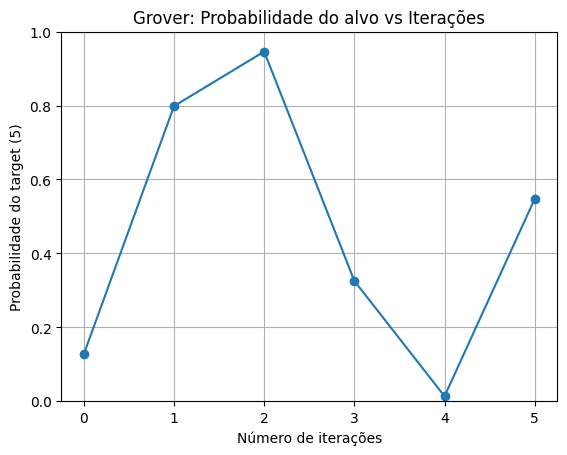

In [ ]:
!pip install cirq --quiet
import cirq
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# CONFIGURAÇÃO
# -----------------------
n_qubits = 3
qubits = cirq.LineQubit.range(n_qubits)

N = 2 ** n_qubits
target = 5

# -----------------------
# ORACLE
# -----------------------
def grover_oracle(target, qubits):
    ops = []

    bits = format(target, f"0{len(qubits)}b")

    for i, bit in enumerate(bits):
        if bit == '0':
            ops.append(cirq.X(qubits[i]))

    ops.append(cirq.H(qubits[-1]))
    ops.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    ops.append(cirq.H(qubits[-1]))

    for i, bit in enumerate(bits):
        if bit == '0':
            ops.append(cirq.X(qubits[i]))

    return ops

# -----------------------
# DIFFUSION
# -----------------------
def diffusion(qubits):
    ops = []
    ops.append(cirq.H.on_each(*qubits))
    ops.append(cirq.X.on_each(*qubits))

    ops.append(cirq.H(qubits[-1]))
    ops.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    ops.append(cirq.H(qubits[-1]))

    ops.append(cirq.X.on_each(*qubits))
    ops.append(cirq.H.on_each(*qubits))

    return ops

# -----------------------
# SIMULADOR
# -----------------------
simulator = cirq.Simulator()

iterations_list = []
probabilities = []

# -----------------------
# TESTE POR ITERAÇÕES
# -----------------------
max_iter = 6  # suficiente para N=8

for k in range(max_iter):
    circuit = cirq.Circuit()

    # estado inicial
    circuit.append(cirq.H.on_each(*qubits))

    # aplica k iterações de Grover
    for _ in range(k):
        circuit.append(grover_oracle(target, qubits))
        circuit.append(diffusion(qubits))

    circuit.append(cirq.measure(*qubits, key="result"))

    # simula várias vezes
    result = simulator.run(circuit, repetitions=2000)
    hist = result.histogram(key="result")

    # probabilidade do target
    prob = hist.get(target, 0) / 2000

    iterations_list.append(k)
    probabilities.append(prob)

# -----------------------
# GRÁFICO
# -----------------------
plt.plot(iterations_list, probabilities, marker='o')

plt.title("Grover: Probabilidade do alvo vs Iterações")
plt.xlabel("Número de iterações")
plt.ylabel("Probabilidade do target (5)")
plt.ylim(0, 1)

plt.grid()
plt.show()